# Saliency maps tutorial

In order to generate saliency maps, you need the dataset in the proper format (see the [prepare data tutorial](https://meegnet.readthedocs.io/en/latest/preparedata.html), and an architecture, trained or not (seeing saliency maps with an untrained architecture should be noise).

The first step to generating visualisation for the saliency maps will be to first compute the saliency maps.

## Generate Saliency maps

First we will set all the needed imports

In [1]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np
from tqdm import tqdm
from meegnet.dataloaders import EpochedDataset
from meegnet.network import Model
from meegnet.viz import compute_saliency_maps

/home/arthur/github/meegnet/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This next section sets up all the parameters we will need for the saliency maps computations

In [2]:
# We set up our data to be 3 channel types (MAG GRAD GRAD),
# 102 sensor locations (Elekta Neuromag Vector View 306 channel MEG),
# and 400 time samples for 800ms of signal sampled as 500Hz.
n_channels = 'ALL'
input_size = (3, 102, 400)
sfreq = 500

n_outputs = 2  # using auditory vs visual stimulus classification -> 2 classes
n_subjects = 1000
n_samples = None  # We will use all trials for each subject

net_option = 'eegnet'
confidence = 0.90

# setting up a seed for reproducibility (will be used for numpy, pandas, torch, and the meegnet library)
seed = 42

# Setting up paths
classif = 'eventclf'  # also used for naming files and for model name
save_path = f'/home/arthur/camcan/{classif}'
model_path = save_path
data_path = os.path.join(save_path, f'downsampled_{sfreq}')

# name of the model
name = f'{classif}_{net_option}_{seed}_{n_channels}'

### Loading the Model

Loading the model from pretrained, using the from_pretrained method, can also load another model using the load method. It is also possible to comment both lines in order to use an untrained model.

Model Loaded.


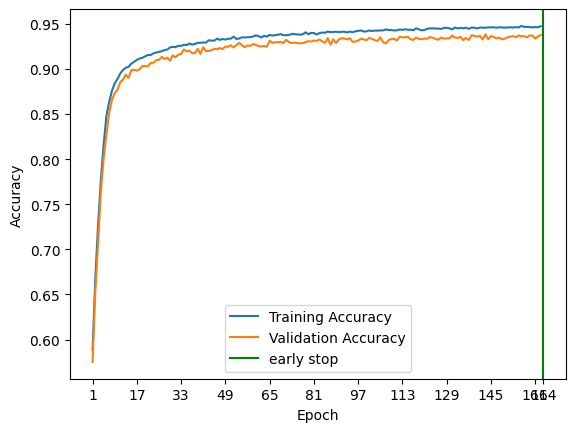

In [3]:
my_model = Model(name, net_option, input_size, n_outputs, save_path=save_path)
# my_model.from_pretrained()
model_path = os.path.join(save_path, name + '.pt')
my_model.load(model_path)
print('Model Loaded.')

my_model.plot_accuracy();

### Loading data

If the data was set-up correctly, we use participands_info.csv in order to generate a subject list and select a random subject for generating figures.

In [4]:
csv_file = os.path.join(save_path, f'participants_info.csv')
dataframe = pd.read_csv(csv_file, index_col=0).sample(frac=1, random_state=seed).reset_index(drop=True)[:n_subjects]
subj_list = dataframe['sub'].tolist()
np.random.seed(seed)

### Compute Saliency maps

Finally, we compute the saliency maps and save them.

In [5]:
# This will create a saliency maps path inside the save path
# Please don't change or it might break code later on
sal_path = os.path.join(save_path, 'saliency_maps', name, f'{confidence}confidence')
if not os.path.exists(sal_path):
	os.makedirs(sal_path)

for sub in tqdm(subj_list):
	# The next two lines allow to pick-up where we left off and not compute saliencies each time this cell is ran.
	sub_files = [filename for filename in os.listdir(sal_path) if sub in filename]
	if len(sub_files) != n_outputs * 2:  # 2 file (positive and negative saliencies) per label.
		dataset = EpochedDataset(
			sfreq=sfreq,  # sampling frequency of 500Hz
			n_subjects=n_subjects,
			n_samples=n_samples,
			sensortype='ALL',  # we use MAG GRAD GRAD here
			lso=True,
			random_state=seed,
		)
		dataset.load(save_path, one_sub=sub)
		if len(dataset) > 0:
			compute_saliency_maps(
				dataset, dataset.target_labels, sub, sal_path, my_model.net, threshold=confidence, epoched=True
			)

dataset = EpochedDataset(
	sfreq=sfreq,
	n_subjects=n_subjects,
	n_samples=n_samples,
	sensortype='ALL',  # we use MAG GRAD GRAD here
	lso=True,
	random_state=seed,
)
dataset.load(data_path, one_sub=sub)
labels = dataset.target_labels.tolist()

100%|██████████| 554/554 [00:00<00:00, 1073.01it/s]


### Generating figures

In the case of epoched data with fixed timing, it might be interresting to look at the saliency at specific timings.

In [6]:
stim_tick = 150  # The timing for the stimulus is 150ms

sensors = ['Magnetometers (102 channels)', 'Gradiometers (204 channels)']
saliency_types = ('pos', 'neg')
cmap = 'coolwarm'

fig_path = os.path.join(save_path, 'figures', name)
if not os.path.exists(fig_path):
	os.makedirs(fig_path)

info = np.load('../camcan_sensor_locations.npy', allow_pickle=True).tolist()

print(f'Generating figure for sensors: {sensors}')
print(f'For the visual vs resting state classification')

all_saliencies = defaultdict(lambda: defaultdict(lambda: []))

# First load all computed saliencies
for i, sub in enumerate(tqdm(subj_list)):
	sub_saliencies = defaultdict(lambda: {})
	for label in labels:
		nofile = False
		for saliency_type in saliency_types:
			lab = f'_{label}'
			saliency_file = os.path.join(sal_path, f'{sub}{lab}_{saliency_type}_sal_{confidence}confidence.npy')
			if os.path.exists(saliency_file):
				try:
					saliencies = np.load(saliency_file)
					sub_saliencies[saliency_type][label] = saliencies
				except IOError:
					logging.warning(f'Error loading {saliency_file}')
					nofile = True
					continue
			else:
				nofile = True
				continue
			if len(saliencies.shape) == 3:
				saliencies = saliencies[np.newaxis, ...]  # If only one saliency in file
			elif len(saliencies.shape) != 4:
				nofile = True
				continue
			all_saliencies[saliency_type][label].append(saliencies.mean(axis=0))

		if nofile:
			continue

for label in labels:
	for saliency_type in saliency_types:
		if type(all_saliencies[saliency_type][label]) is list:
			all_saliencies[saliency_type][label] = np.array(all_saliencies[saliency_type][label])

Generating figure for sensors: ['Magnetometers (102 channels)', 'Gradiometers (204 channels)']
For the visual vs resting state classification


100%|██████████| 554/554 [00:59<00:00,  9.28it/s]


In [7]:
def get_saliency_data(saliency_dict):
	saliencies = {}
	# operation = lambda a, b: (a+b)/2
	for lab, pos in saliency_dict['pos'].items():
		if len(pos.shape) >= 3:
			pos = np.array(pos)
			pos = np.array([pos[:, 0], np.maximum(pos[:, 1], pos[:, 2])])
			pos = pos.swapaxes(0, 1)
			neg = np.array(saliency_dict['neg'][lab])
			neg = np.array([neg[:, 0], np.maximum(neg[:, 1], neg[:, 2])])
			neg = neg.swapaxes(0, 1)
			saliencies[lab] = pos - neg
	return saliencies


data_dict = get_saliency_data(all_saliencies)
final_dict = {key: np.mean(val, axis=0)[np.newaxis] for key, val in data_dict.items()}

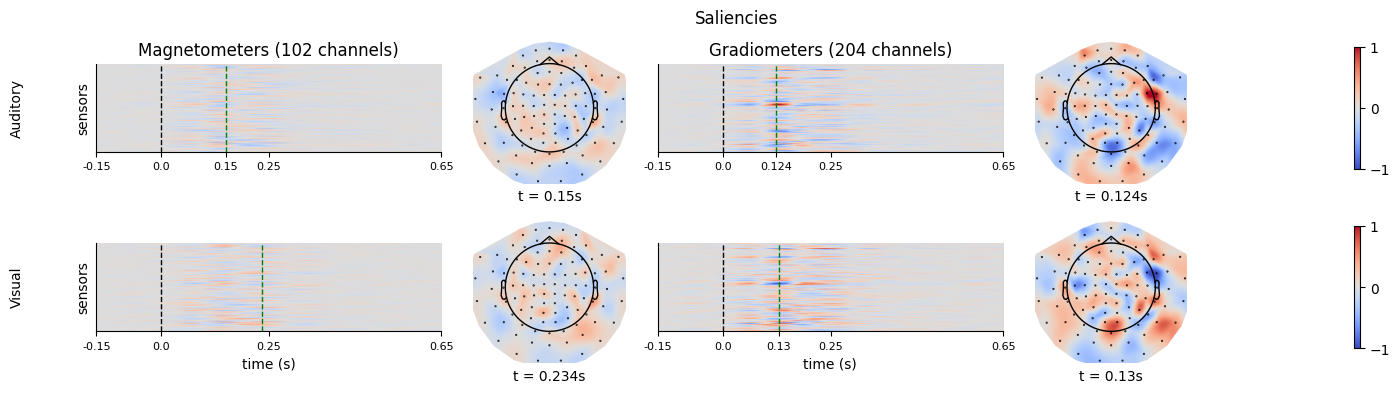

In [8]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import copy
from mne.viz import plot_topomap

outlines = None
saliencies = copy.copy(final_dict)
edge = 0
suffix = ''
title = 'Saliencies'
topomap = 'timing'

block_size = 3
tick_ratio = 1000 / 500
padding = int(edge / tick_ratio)
if stim_tick is not None:
	assert stim_tick > edge, "Can't have stim_tick lower than the edge parameter."
if suffix != '' and not suffix.endswith('_'):
	suffix += '_'
n_blocs = len(sensors)  # number of blocs of figures in a line
n_lines = len(saliencies)  # number of lines for the pyplot figure
n_cols = n_blocs * block_size + 1  # number of columns for the pyplot figure
grid = GridSpec(n_lines, n_cols)
fig = plt.figure(figsize=(n_cols * 2, n_lines * 2))
plt.title(title)
plt.axis('off')
axes = []
# First pass to gather vlim values:
for i, label in enumerate(saliencies.keys()):
	vlim = 0
	gradient = copy.copy(saliencies[label]).squeeze()
	assert len(gradient) == n_blocs, (
		"Can't generate figures for all sensors, check if the saliencies have been properly computed."
	)
	gradient /= np.abs(gradient).max()
	for j, sensor_type in zip(range(0, n_blocs * block_size, block_size), sensors):
		idx = j // block_size
		length = gradient[idx].shape[1]
		grads = copy.copy(gradient[idx])[:, padding : length - padding]
		# segment_length = grads.shape[1]
		# mid_slice = (0, segment_length)
		# gradmeans = grads[:, mid_slice[0] : mid_slice[1]].mean(axis=1)[:, np.newaxis]
		# grads -= gradmeans  # We remove mean accross time to make the variations accross time pop-up more
		vmax = grads.max()
		vmin = grads.min()
		vlim_curr = max(abs(vmax), abs(vmin))
		if vlim_curr > vlim:
			vlim = vlim_curr

	for j, sensor_type in zip(range(0, n_blocs * block_size, block_size), sensors):
		idx = j // block_size
		# grads = gradient[idx]
		# In an attempt to remove the edge effect:
		# We remove the first and last edge points -> therefore tick is moved to 25 (was 75)
		length = gradient[idx].shape[1]
		grads = gradient[idx][:, padding : length - padding]

		segment_length = grads.shape[1]
		# We add the mid_slice variable in an attempt to tackle the edge effects by removing mean from center values for example
		# But it was uneffective. This could still be useful so we leave it here...
		# mid_slice = (0, segment_length)
		# mid_slice = (int(segment_length / 4), int(3 * segment_length / 4))
		# gradmeans = grads[:, mid_slice[0] : mid_slice[1]].mean(axis=1)[:, np.newaxis]
		# grads -= gradmeans  # We remove mean accross time to make the variations accross time pop-up more
		n_sensors = grads.shape[0]
		max_idx = np.unravel_index(abs(grads).argmax(), grads.shape)[1]
		# max_idx = np.argmax([avg_range(arr) for arr in grads.T])
		# max_idx = np.argmax(np.mean(grads, axis=0))
		axes.append(fig.add_subplot(grid[i, j : j + 2]))
		plt.imshow(grads, interpolation=None, aspect=1, vmin=-vlim, vmax=vlim, cmap=cmap)
		axes[-1].spines['top'].set_visible(False)
		axes[-1].spines['right'].set_visible(False)
		axes[-1].yaxis.tick_right()

		x_ticks = [0, int(segment_length / 2), segment_length]

		if stim_tick is not None:
			stim_tick_index = int(stim_tick / tick_ratio)
			x_ticks.append(stim_tick_index)
			plt.axvline(x=stim_tick_index, color='black', linestyle='--', linewidth=1)
		else:
			stim_tick_index = 0

		if topomap != 'average':
			plt.axvline(x=max_idx, color='green', linestyle='--', linewidth=1)
			if all([abs(x_tick - max_idx) > 10 for x_tick in x_ticks]):
				x_ticks.append(max_idx)

		x_ticks = sorted(x_ticks)
		tick_labels = [(x_tick - stim_tick_index) * tick_ratio / 1000 for x_tick in x_ticks]
		tick_labels[0] += edge
		tick_labels[-1] -= edge

		plt.xticks(x_ticks, tick_labels, fontsize=8)
		# plt.yticks([0, n_sensors], [n_sensors, 0])
		axes[-1].set_yticks([])

		if j == 0:
			axes[-1].text(-100, 50, label.capitalize(), ha='left', va='center', rotation='vertical')
		if idx == n_blocs - 1:
			axes[-1].yaxis.set_label_position('right')
			# plt.ylabel("sensors")
		if i == 0:
			plt.title(sensor_type)
		if i == 1:
			plt.xlabel('time (s)')
		if idx == 0:
			axes[-1].set_ylabel('sensors')
		axes.append(fig.add_subplot(grid[i, j + 2]))
		if topomap == 'timing':
			data = grads[:, max_idx]
		elif topomap == 'window':
			start = max_idx - int(segment_length / 8)
			end = max_idx + int(segment_length / 8)
			if start < 0:
				start = 0
				end = start + int(segment_length / 4)
			elif end > segment_length:
				end = segment_length
				start = block_size * int(segment_length / 4)
			data = grads[:, start:end].mean(axis=1)
		else:
			data = grads.mean(axis=1)

		if isinstance(info, str):
			linfo = np.load(os.path.join(info, f'camcan_info_{sensor_type.lower()}.npy'), allow_pickle=True).tolist()
		else:
			linfo = info
		im, _ = plot_topomap(
			data.ravel(),
			linfo,
			res=300,
			cmap=cmap,
			# cmap='viridis',
			# vlim=(0, vlim),
			vlim=(-vlim, vlim),
			contours=0,
			axes=axes[-1],
			sphere=0.1,
			show=False,
		)
		axes[-1].set_xlabel(f't = {(max_idx * tick_ratio - stim_tick) / 1000}s')

		if idx == n_blocs - 1:
			axes.append(fig.add_subplot(grid[i, n_blocs * 3]))

			fig.colorbar(
				im,
				ax=axes[-1],
				location='right',
				shrink=0.8,
				ticks=(-vlim, 0, vlim),
				# ticks=(0, vlim),
			)
			axes[-1].axis('off')

out_path = os.path.join(fig_path, f'all_subjects_saliencies_{int(confidence * 100)}p_confidence.png')
plt.tight_layout()
plt.savefig(out_path, dpi=300)

In [9]:
from sklearn.decomposition import PCA

ch_types = ['MAG', 'GRAD']
info = np.load(f'../camcan_info_mag.npy', allow_pickle=True).tolist()

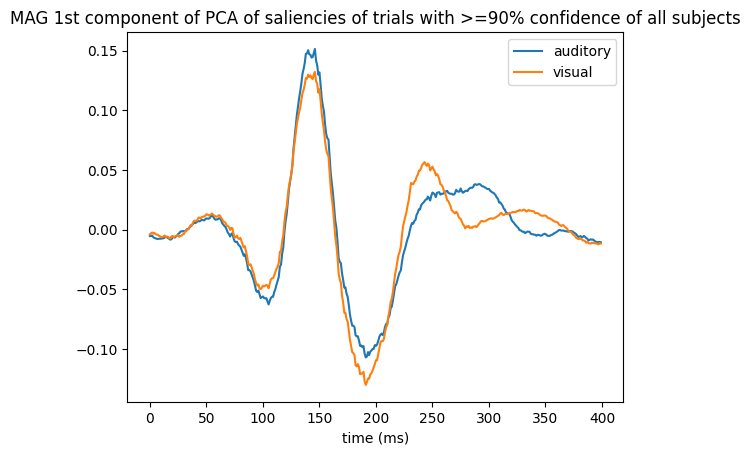

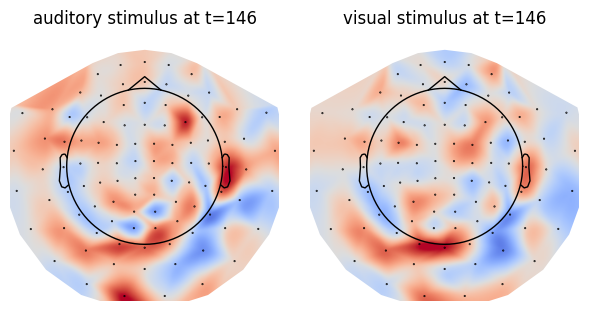

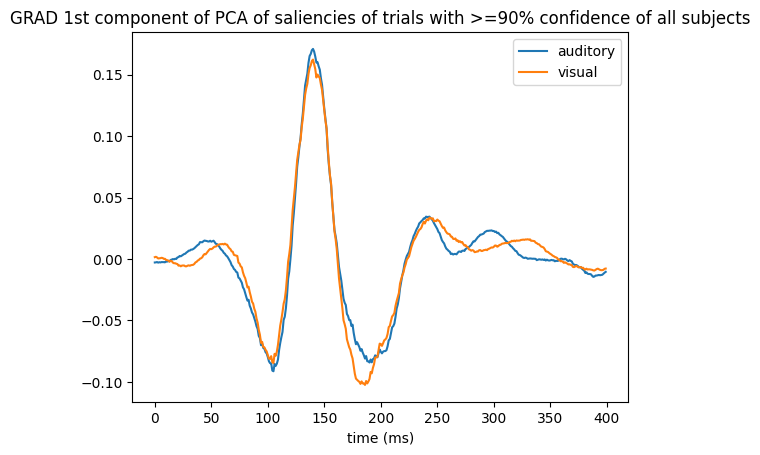

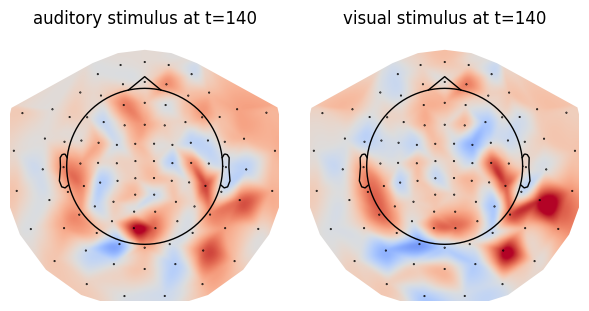

<Figure size 640x480 with 0 Axes>

In [10]:
from mne.viz import plot_topomap

for j, ch_type in enumerate(ch_types):
	# colors = ['y', 'r']
	best_timings = {}
	for i, lab in enumerate(labels):
		pca = PCA(100)
		pca.fit(saliencies[lab].squeeze()[j])
		data = pca.components_[0]
		plt.plot(data)
		# plt.axvline(x=np.argmax(data), color=colors[i])
		best_timings[lab] = data.argmax()

	plt.legend(labels)
	plt.xlabel('time (ms)')
	plt.title(f'{ch_type} 1st component of PCA of saliencies of trials with >=90% confidence of all subjects')
	out_path = os.path.join(fig_path, f'{ch_type}_all_saliencies_{confidence}_temporal_PCA.png')
	plt.savefig(out_path, dpi=300)
	plt.show()
	plt.close()
	fig, axes = plt.subplots(figsize=(6, 3), nrows=1, ncols=2, layout='constrained')

	for i, lab in enumerate(labels):
		pca = PCA(100)
		pca.fit(data_dict[lab][:, j, :, best_timings[lab]])
		data = pca.components_.T
		im, _ = plot_topomap(data[:, 0], info, axes=axes[i], res=300, contours=0, cmap=cmap, sphere=0.1, show=False)
		axes[i].set_title(f'{lab} stimulus at t={best_timings[lab]}')

	plt.show()
	plt.close()
	out_path = os.path.join(fig_path, f'{ch_type}_t{best_timings[lab]}_all_saliencies_{confidence}_spatial_PCA.png')
	plt.savefig(out_path, dpi=300)